# Model Building on the Other stem first

In [2]:
import os
import librosa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import tensorflow as tf
#libraries for building the model
from tensorflow.keras.layers import BatchNormalization, Conv2D,MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [3]:
##loading the other data(mel's) and lables
other_data = np.load(f'processed_data/other_features.npy')
other_labels = np.load(f'processed_data/other_labels.npy')

In [4]:
print(other_data.shape)
print(other_labels.shape)

(10198, 150, 150, 1)
(10198,)


## 3 way data split
80% Training: To teach the model.

10% Validation: To check for "Overfitting" during the training process.

10% Test: To give a final, unbiased accuracy score at the very end.

In [5]:
# shuffling is need cause we added the data in a sequential order first bollypop then carnatic so data inside data is in order
#stratify keep the proportion of data same in both test and train
from sklearn.model_selection import train_test_split

# this single line splits and shuffles at the same time
X_train, X_temp, Y_train, Y_temp = train_test_split(
    other_data,
    other_labels,
    test_size=0.2,
    random_state=42,
    shuffle=True, # be default it is true
    stratify=other_labels # Ensures 20% of EACH genre goes to the test set
)


#20 % remaining data in temp
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.5,
    random_state=42,
    shuffle=True, # be default it is true
    stratify= Y_temp # Ensures 20% of EACH genre goes to the test set
)
# Summary of the "Shuffling" Timeline
# During Split: Handled by train_test_split(shuffle=True). (Do this now)
# During Training: Handled by model.fit(shuffle=True). (Do this later)
# now ready for normalization

In [6]:
print(X_train.shape)
print(Y_train.shape)
print(X_val.shape)
print(Y_val.shape)
print(X_test.shape)
print(Y_test.shape)

(8158, 150, 150, 1)
(8158,)
(1020, 150, 150, 1)
(1020,)
(1020, 150, 150, 1)
(1020,)


## data normalization

In [7]:
other_data[:1]

# the values are in decibels(power_to_db) when converted to mel scale
# need to normalize the value form 0 to 1

array([[[[-48.452854],
         [-48.11557 ],
         [-49.23192 ],
         ...,
         [-47.95298 ],
         [-44.208584],
         [-39.58476 ]],

        [[-48.672886],
         [-43.46166 ],
         [-42.037247],
         ...,
         [-47.11456 ],
         [-45.67823 ],
         [-43.559166]],

        [[-54.899876],
         [-43.74206 ],
         [-40.584118],
         ...,
         [-45.917923],
         [-43.058113],
         [-40.126766]],

        ...,

        [[-79.950966],
         [-80.      ],
         [-80.      ],
         ...,
         [-80.      ],
         [-74.35068 ],
         [-63.332966]],

        [[-80.      ],
         [-80.      ],
         [-80.      ],
         ...,
         [-80.      ],
         [-74.50041 ],
         [-63.504673]],

        [[-80.      ],
         [-80.      ],
         [-80.      ],
         ...,
         [-80.      ],
         [-74.47734 ],
         [-63.471592]]]], dtype=float32)

## Normalization from (-80 - 0)  to  0 - 1 
The "Golden Rule": Split First, Normalize Second
Many beginners make the mistake of normalizing the entire dataset (all 10,000 samples) and then splitting it. This causes Data Leakage.
Why? Normalization (like Min-Max Scaling) uses the min and max values of your data. If you normalize the whole set before splitting, your training data "knows" the maximum value of the test set. This "future information" leaks into your model, making your training accuracy look artificially high while your real-world performance fails.
The Correct Way: 
1.  Split your data into $X_{train}$ and $X_{test}$.
2.  Calculate the min and max using only $X_{train}$.
3.  Apply that same scaling to both $X_{train}$ and $X_{test}$.

In [8]:
# 1. Calculate stats from TRAINING data only
# This represents the "known world" to the model
# min and max of x_train only
X_min = X_train.min()
X_max = X_train.max()

# 2. Apply the same scaling to all three sets
# This squishes all dB values into a 0.0 to 1.0 range
X_train = (X_train - X_min) / (X_max - X_min)
X_val = (X_val - X_min) / (X_max - X_min)
X_test = (X_test - X_min) / (X_max - X_min)

# 3. Verification - Essential Check!
print("--- Normalization Audit ---")
print(f"Train Range: {X_train.min()} to {X_train.max()}") # Must be 0.0 to 1.0
print(f"Val Range:   {X_val.min():.2f} to {X_val.max():.2f}")
print(f"Test Range:  {X_test.min():.2f} to {X_test.max():.2f}")

--- Normalization Audit ---
Train Range: 0.0 to 1.0
Val Range:   0.00 to 1.00
Test Range:  0.00 to 1.00


### One hot encoding when to use for labels 

In [9]:
# In your current project, you actually don't need to do one-hot encoding because of the specific loss function we chose. However, understanding when to use it is a "rite of passage" for any AI developer.

# Here is the breakdown of when to use it and when to skip it.

# 1. The "Loss Function" Rule
# The decision to use one-hot encoding is tied directly to which Loss Function you pick in model.compile():

# Scenario A: Integer Labels (0, 1, 2, 3, 4)

# Use: loss='sparse_categorical_crossentropy'

# Decision: Do NOT one-hot encode.

# Why: Keras handles the math internally. This is more memory-efficient because you aren't creating a huge matrix of zeros. (This is your current setup).

# Scenario B: One-Hot Labels ([1,0,0,0,0], [0,1,0,0,0]...)

# Use: loss='categorical_crossentropy'

# Decision: Yes, one-hot encode.

# Why: You use this when you want the model to output "probabilities" that exactly match a target vector.

## Building the CNN Architecture

link : https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks/

In [10]:
# consists of convulations, pooling, flatening(fully connected), dense and dropout
# using the sequential modle(layer stacking)
# allows group layers together and the output of one layers is the input for other layer

model = tf.keras.models.Sequential()


In [39]:
classes = ['bollypop', 'carnatic', 'ghazal', 'semiclassical', 'sufi']

In [11]:
mel_shape = X_train[0].shape
#it is just the one melspectrogram(one chunk out of multiple chunks of one audio file)
#and it has 210*210 - 44100 elements

## Adding the layers

In [12]:
# block 1
model.add(Conv2D(filters = 32, kernel_size= 3, padding= 'same', activation= 'relu', input_shape = mel_shape ))
model.add(BatchNormalization()) # Added

model.add(Conv2D(filters= 32, kernel_size = 3, activation = 'relu'))
model.add(BatchNormalization()) # Added

model.add(MaxPool2D(pool_size=2, strides = 2))


          

In [13]:
# block 2
model.add(Conv2D(filters= 64, kernel_size = 3, padding = 'same', activation= 'relu')) #input shape will be there 
                                                                                    # same as first layers(no need to give again)
model.add(BatchNormalization()) # Added

model.add(Conv2D(filters = 64, kernel_size = 3, activation= 'relu'))
model.add(BatchNormalization()) # Added

model.add(MaxPool2D(pool_size = 2, strides = 2))

In [14]:
# block 3
model.add(Conv2D(filters= 128, kernel_size = 3, padding = 'same', activation= 'relu')) #input shape will be there 
                                                                                    # same as first layers(no need to give again)
model.add(BatchNormalization()) # Added

model.add(Conv2D(filters = 128, kernel_size = 3, activation= 'relu'))
model.add(BatchNormalization()) # Added

model.add(MaxPool2D(pool_size = 2, strides = 2))

In [15]:
# drop some features to overcome overfitting

model.add(Dropout(0.3)) #-> dropping 30% neurons

In [16]:
# block 4
model.add(Conv2D(filters= 256, kernel_size = 3, padding = 'same', activation= 'relu')) #input shape will be there 
                                                                                    # same as first layers(no need to give again)
model.add(BatchNormalization()) # Added

model.add(Conv2D(filters = 256, kernel_size = 3, activation= 'relu'))
model.add(BatchNormalization()) # Added

model.add(MaxPool2D(pool_size = 2, strides = 2))

In [17]:
# #block 6
# model.add(Conv2D(filters= 512, kernel_size = 3, padding = 'same', activation= 'relu')) #input shape will be there 
#                                                                                     # same as first layers(no need to give again)
# model.add(Conv2D(filters = 512, kernel_size = 3, activation= 'relu'))

# model.add(MaxPool2D(pool_size = 2, strides = 2))


In [18]:
model.add(Dropout(0.4))

#### Flatten and Dense

In [19]:
model.add(Flatten())
# Fully Connected (FC)The fully connected layer (FC) operates on a flattened input where each input is 
# connected to all neurons. If present, FC layers are usually found towards the end of CNN architectures
# and can be used to optimize objectives such as class scores.

In [20]:
#constructing the hidden layers, units are neuron and value activation func is relu(as sigmoid is costly(may be on CPU resourses)
model.add(Dense(units = 512, activation = 'relu'))

In [21]:
model.add(Dropout(0.5))

In [22]:
#final output layer
model.add(Dense(units=len(classes), activation = 'softmax'))

In [23]:
model.summary()
# The parameters here are the extracted features from the mel's by conv2d(extraction), pooling(max,avg value extraction)
# and the dropout(removal) again repeating and increasing filters , hence it just increases

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      320       
                                                                 
 batch_normalization (BatchN  (None, 150, 150, 32)     128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 148, 148, 32)      9248      
                                                                 
 batch_normalization_1 (Batc  (None, 148, 148, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 74, 74, 32)       0         
 )                                                               
                                                        

## Compiling the Model

In [24]:
model.compile(optimizer = Adam(learning_rate = 0.0001), loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])
#loss = sparse_categorical_crossentropy, no one hot encoding needed

## Training the Model

In [25]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Stop if the model doesn't improve for 8 epochs
early_stopping = EarlyStopping(
    monitor='val_accuracy', 
    patience=8, 
    restore_best_weights=True # This is the most important part!
)

# 2. Lower learning rate if progress stalls (helps get that extra 2-3%)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=4, 
    min_lr=0.00001
)

In [26]:
training_history = model.fit(
    X_train, Y_train,
    epochs= 50,
    batch_size= 64,
    validation_data=(X_val, Y_val),
    callbacks=[early_stopping, reduce_lr]
    )

Epoch 1/50
128/128 [==============================] - 37s 216ms/step - loss: 1.8914 - accuracy: 0.3473 - val_loss: 5.0028 - val_accuracy: 0.2049 - lr: 1.0000e-04
Epoch 2/50
128/128 [==============================] - 23s 179ms/step - loss: 1.3343 - accuracy: 0.4461 - val_loss: 7.0781 - val_accuracy: 0.2049 - lr: 1.0000e-04
Epoch 3/50
128/128 [==============================] - 23s 179ms/step - loss: 1.1770 - accuracy: 0.5222 - val_loss: 4.3522 - val_accuracy: 0.2510 - lr: 1.0000e-04
Epoch 4/50
128/128 [==============================] - 23s 179ms/step - loss: 1.0560 - accuracy: 0.5693 - val_loss: 2.5658 - val_accuracy: 0.3020 - lr: 1.0000e-04
Epoch 5/50
128/128 [==============================] - 23s 180ms/step - loss: 0.9635 - accuracy: 0.6138 - val_loss: 2.3988 - val_accuracy: 0.3520 - lr: 1.0000e-04
Epoch 6/50
128/128 [==============================] - 23s 180ms/step - loss: 0.8778 - accuracy: 0.6467 - val_loss: 0.8293 - val_accuracy: 0.6833 - lr: 1.0000e-04
Epoch 7/50
128/128 [========

In [28]:
# Save in the modern Keras format
model.save('indian_music_classifier_v2.h5') 
print("Model saved as indian_music_classifier_v2.h5")

Model saved as indian_music_classifier_v2.h5


In [ ]:
what changes i made in this version 2:

1. batch BatchNormalization - for generalizatino(as seen in the summaray the Conv2D layers remains same in input shape only
                                                 get max reduce my max pool)

2. drop out value increase
-- 3 times Use 
0.3, 0.4, 0.5

3.units = 512 in dense first layers - helps to reduce the size for memorization (previously was 1200 more size)

4. EarlyStopping by two functions, and ReduceLROnPlateau(learning rate adjustor based on val accuracy)

In [32]:
training_history.history
# model

{'loss': [1.8914293050765991,
  1.334346890449524,
  1.1770460605621338,
  1.055998682975769,
  0.9635114669799805,
  0.8778183460235596,
  0.7847963571548462,
  0.7189045548439026,
  0.6430777311325073,
  0.5900720953941345,
  0.5331635475158691,
  0.48093631863594055,
  0.4274604916572571,
  0.3828624188899994,
  0.32643747329711914,
  0.2925250828266144,
  0.23019780218601227,
  0.20241513848304749,
  0.1964333951473236,
  0.18271733820438385,
  0.1629798859357834,
  0.1583990901708603,
  0.16099928319454193,
  0.15237854421138763,
  0.13574868440628052,
  0.13078804314136505,
  0.12632647156715393,
  0.11752090603113174,
  0.11635424196720123,
  0.1081182137131691,
  0.09830355644226074,
  0.09900090098381042,
  0.0906393975019455],
 'accuracy': [0.3472664952278137,
  0.446065217256546,
  0.522186815738678,
  0.5692571997642517,
  0.6137533783912659,
  0.6467271447181702,
  0.6852169632911682,
  0.7226035594940186,
  0.7431968450546265,
  0.7646481990814209,
  0.7862221002578735,
 

In [ ]:
# big float value error of lr in the last
import json
import numpy as np

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NumpyEncoder, self).default(obj)

# Now saving is a one-liner
with open('training_hist_v2.json', 'w') as f:
    json.dump(training_history.history, f, cls=NumpyEncoder, indent=4)

## Model Evaluation

In [11]:
model = tf.keras.models.load_model("indian_music_classifier_v2.keras")
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      320       
                                                                 
 batch_normalization (BatchN  (None, 150, 150, 32)     128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 148, 148, 32)      9248      
                                                                 
 batch_normalization_1 (Batc  (None, 148, 148, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 74, 74, 32)       0         
 )                                                               
                                                        

In [12]:
import json
with open('training_hist_v2.json', 'r') as json_file:
    training_history = json.load(json_file)

training_history.keys() #it is a dictionary now

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'lr'])

## Evaluation on train and test data

In [13]:
training_loss ,training_accuracy = model.evaluate(X_train, Y_train)

255/255 [==============================] - 12s 31ms/step - loss: 0.0446 - accuracy: 0.9912


In [14]:
val_loss ,val_accuracy = model.evaluate(X_val, Y_val)

32/32 [==============================] - 2s 55ms/step - loss: 0.4095 - accuracy: 0.8735


In [15]:
training_history['loss']

[1.8914293050765991,
 1.334346890449524,
 1.1770460605621338,
 1.055998682975769,
 0.9635114669799805,
 0.8778183460235596,
 0.7847963571548462,
 0.7189045548439026,
 0.6430777311325073,
 0.5900720953941345,
 0.5331635475158691,
 0.48093631863594055,
 0.4274604916572571,
 0.3828624188899994,
 0.32643747329711914,
 0.2925250828266144,
 0.23019780218601227,
 0.20241513848304749,
 0.1964333951473236,
 0.18271733820438385,
 0.1629798859357834,
 0.1583990901708603,
 0.16099928319454193,
 0.15237854421138763,
 0.13574868440628052,
 0.13078804314136505,
 0.12632647156715393,
 0.11752090603113174,
 0.11635424196720123,
 0.1081182137131691,
 0.09830355644226074,
 0.09900090098381042,
 0.0906393975019455]

## Accuracy and loss visualization

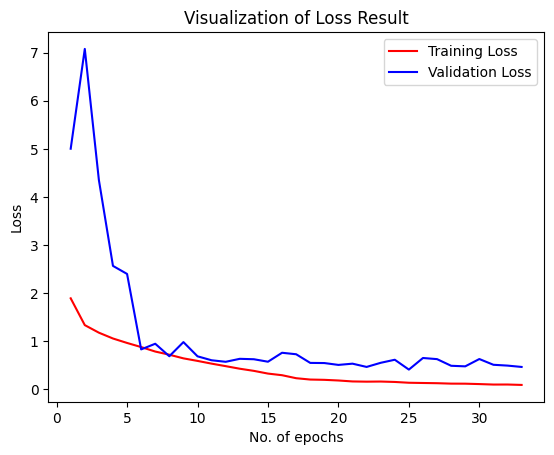

In [16]:
epochs = [i for i in range(1,34)]
plt.plot(epochs, training_history['loss'], label = 'Training Loss',color = 'red' ) 
plt.plot(epochs, training_history['val_loss'], label = 'Validation Loss',color = 'blue' )
plt.xlabel('No. of epochs')
plt.ylabel('Loss')
plt.title('Visualization of Loss Result')
plt.legend()
plt.show()

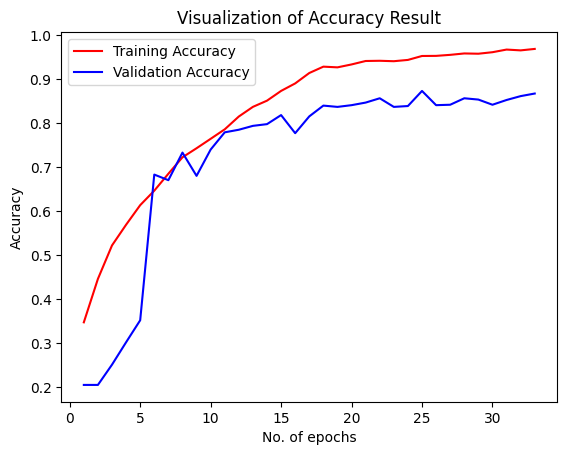

In [17]:
epochs = [i for i in range(1,34)]
plt.plot(epochs, training_history['accuracy'], label = 'Training Accuracy',color = 'red' ) 
plt.plot(epochs, training_history['val_accuracy'], label = 'Validation Accuracy',color = 'blue' )
plt.xlabel('No. of epochs')
plt.ylabel('Accuracy')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

In [18]:
## the loss and accuracy of the training dataset on the model has a smooth curve
## but for the validation(data- test data) it is somewhat close to the training data but need to be
## improved 

## for improving the accuracy and reducing the loss we need to tune the model as discussed on various
## parameters.


## Precision, Recall and Confusion Matrix

In [20]:
X_test.shape

(1020, 150, 150, 1)

In [27]:
y_pred = model.predict(X_test)

#y_pred the predicted labels, y_test the actual labels
y_pred

32/32 [==============================] - 1s 30ms/step


array([[9.95905757e-01, 2.32543994e-06, 3.03171328e-06, 2.72406894e-03,
        1.36467512e-03],
       [4.82015967e-01, 3.01883498e-04, 1.30134607e-02, 1.01257466e-01,
        4.03411180e-01],
       [3.02872959e-05, 1.48844811e-05, 6.79298257e-03, 6.26928173e-03,
        9.86892641e-01],
       ...,
       [7.03382284e-06, 1.53140218e-06, 2.64035916e-04, 4.36834991e-03,
        9.95359004e-01],
       [2.74855893e-06, 2.83407715e-08, 1.54181645e-08, 1.21516688e-02,
        9.87845480e-01],
       [1.24122806e-01, 1.70767990e-07, 2.86453144e-07, 8.43298078e-01,
        3.25786732e-02]], dtype=float32)

In [29]:
y_pred.shape
Y_test.shape

(1020,)

In [34]:
predicted_categories = np.argmax(y_pred, axis = 1)
predicted_categories


# axis = 0
# predicted_categories = np.argmax(y_pred, axis = 0)
# predicted_categories

array([0, 0, 4, ..., 4, 4, 3], dtype=int64)

In [36]:
print(Y_test)
print(predicted_categories)        #now we have both true and predicted labels in a single array

[0 0 3 ... 4 4 3]
[0 0 4 ... 4 4 3]


In [38]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(
    Y_test,
    predicted_categories,
)

cm

array([[176,   1,   7,  11,  14],
       [  5, 176,   6,   2,   4],
       [  0,   0, 208,   1,   0],
       [ 10,   4,  10, 160,  19],
       [  7,   0,   7,   7, 185]], dtype=int64)

In [40]:
print(classification_report(Y_test, predicted_categories,target_names=classes))

               precision    recall  f1-score   support

     bollypop       0.89      0.84      0.86       209
     carnatic       0.97      0.91      0.94       193
       ghazal       0.87      1.00      0.93       209
semiclassical       0.88      0.79      0.83       203
         sufi       0.83      0.90      0.86       206

     accuracy                           0.89      1020
    macro avg       0.89      0.89      0.89      1020
 weighted avg       0.89      0.89      0.89      1020



## Confusion Matrix Visualization

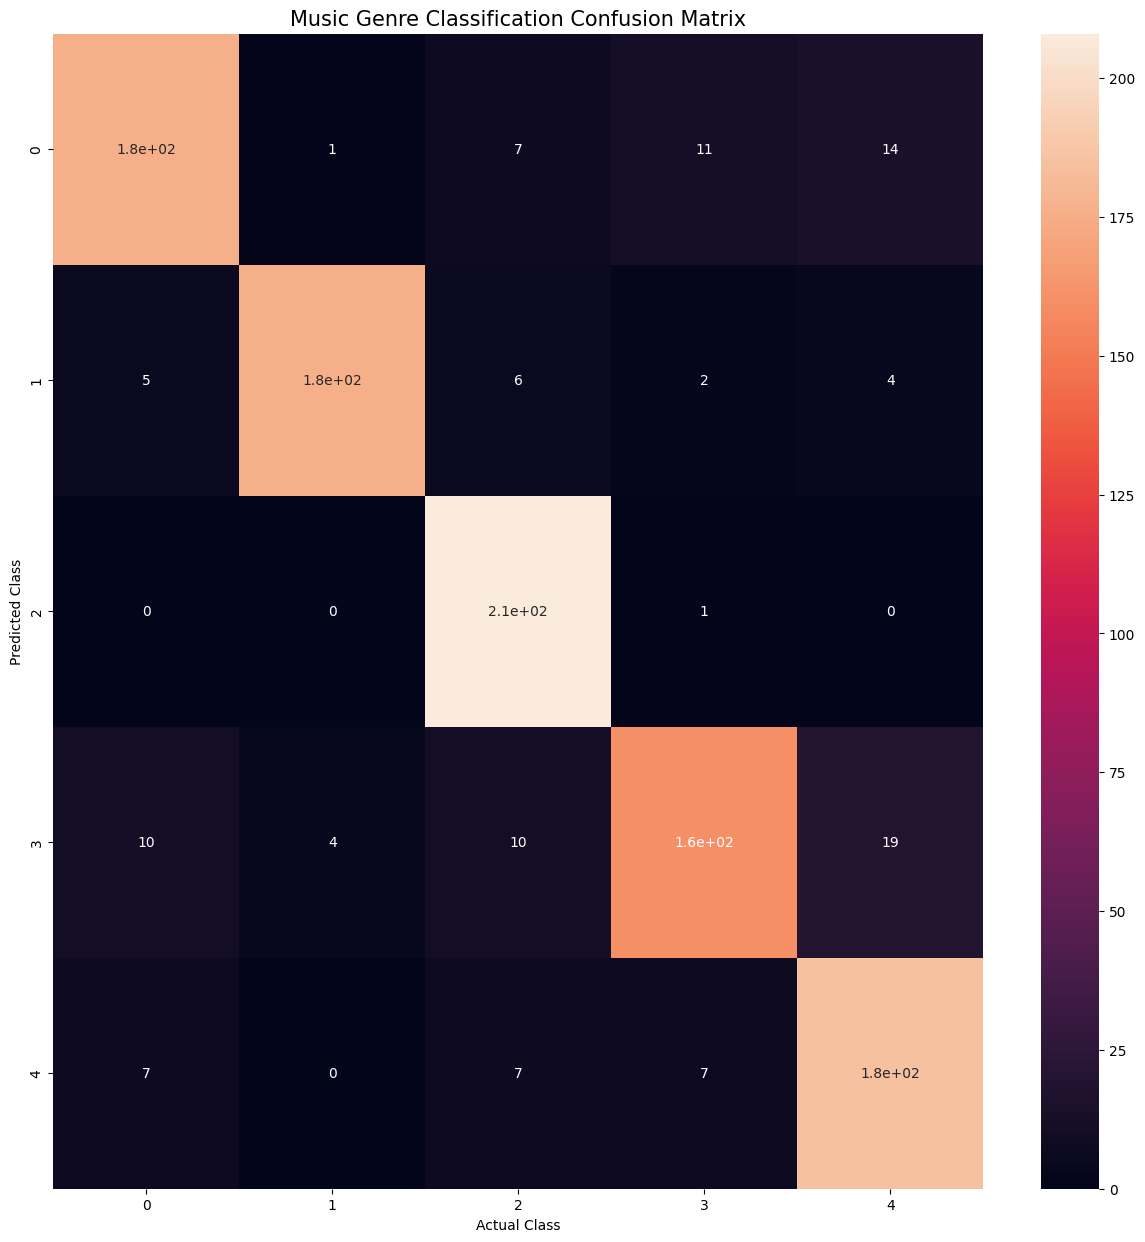

In [42]:
import seaborn as sns
plt.figure(figsize=(15,15))
sns.heatmap(cm,annot=True,annot_kws={"size" : 10})
plt.ylabel("Predicted Class",fontsize=10)
plt.xlabel("Actual Class",fontsize=10)
plt.title("Music Genre Classification Confusion Matrix",fontsize=15)
plt.show()

In [43]:
# most of the values are in the diagonal means the performance of the model is good
# to improve the performance more we have to tune the model(on the parameters discussed earlier)